Problem 4
Number of samples = 100000
Empirical mean = 0.011037950590434394 seconds
Empirical mean = 11.037950590434393 ms
Empirical P(T > 50 ms) = 0.0615


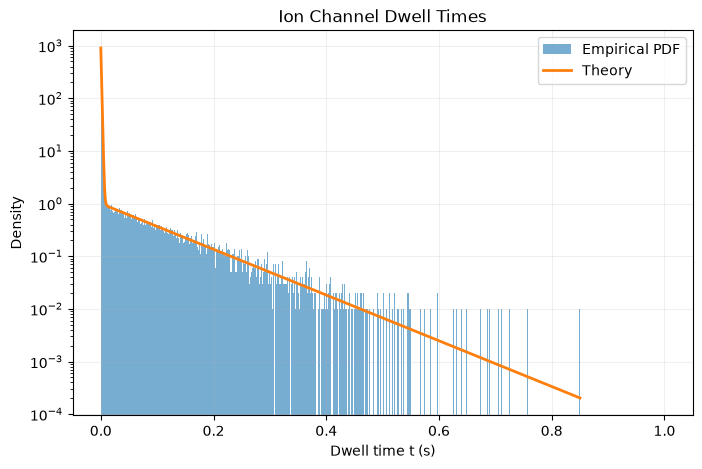

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

N = 10**5
a = 0.9
lambda_f = 1000
lambda_s = 10

rng = np.random.default_rng(2026)


# Generate samples using composition sampling

# Step 1: Choose the component
B = rng.random(N) < a

# Step 2: Choose the corresponding lambda
lam = np.where(B, lambda_f, lambda_s)

# Step 3: Generate exponential sample
U = rng.random(N)
T = -np.log(U) / lam


# Empirical results

empirical_mean = np.mean(T)
empirical_tail = np.mean(T > 0.05)

print("======================================")
print("Problem 4")
print("======================================")

print("Number of samples =", N)
print("Empirical mean =", empirical_mean, "seconds")
print("Empirical mean =", empirical_mean * 1000, "ms")
print("Empirical P(T > 50 ms) =", empirical_tail)


# Plot

# Bin width = 1 ms
bin_width = 0.001

bins = np.arange(
    0,
    np.ceil(T.max()) + bin_width,
    bin_width
)

plt.figure(figsize=(8, 5))

plt.hist(
    T,
    bins=bins,
    density=True,
    alpha=0.6,
    label="Empirical PDF"
)


# Theoretical PDF

x = np.linspace(0, min(1, T.max()), 1000)

f = (
    a * lambda_f * np.exp(-lambda_f * x)
    + (1 - a) * lambda_s * np.exp(-lambda_s * x)
)

plt.plot(
    x,
    f,
    linewidth=2,
    label="Theory"
)


plt.xlabel("Dwell time t (s)")
plt.ylabel("Density")
plt.title("Ion Channel Dwell Times")
plt.yscale("log")

plt.legend()
plt.grid(alpha=0.2)


plt.savefig(
    os.path.expanduser("~/Downloads/problem4_plot.pdf"),
    bbox_inches="tight"
)

plt.show()